# Nelson-Siegel Yield Curve Fitting

## Objective

Fit a **Nelson-Siegel yield curve model** to observed bond market yield data using nonlinear regression.

The Nelson-Siegel model is widely used in finance to model the shape of the yield curve across different bond maturities.

---

## Nelson-Siegel Model

The yield curve is modeled as:

$$
y(T)=\beta_0+\beta_1\left(\frac{1-e^{-T/\tau}}{T/\tau}\right)
+\beta_2\left(
\frac{1-e^{-T/\tau}}{T/\tau}-e^{-T/\tau}
\right)
$$

where:

- $T$ = time to maturity (years)

- $y(T)$ = bond yield

- $\beta_0$ = long-term yield level

- $\beta_1$ = short-term slope factor

- $\beta_2$ = medium-term curvature factor

- $\tau$ = decay parameter controlling the curve shape



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
T = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])

yields = np.array([4.92, 4.81, 4.63, 4.38, 4.21,
                   4.05, 4.00, 4.08, 4.32, 4.45])

In [ ]:
def Nelson_Siegel_Function(T,beta_0,beta_1,beta_2,tau):
  term_1 = (1-np.exp(-T/tau))/(T/tau)
  term_2 = term_1 - np.exp(-T/tau)
  bond_yield = beta_0+beta_1*term_1+beta_2*term_2
  return bond_yield

In [ ]:
initial_guesses = [4.5,0.5,-1.0,2.0]

In [ ]:
parameters, covariance_matrix = curve_fit(Nelson_Siegel_Function,xdata=T,ydata=yields,p0=initial_guesses,maxfev = 100000)

In [ ]:
beta_0,beta_1, beta_2, tau = parameters
uncertainties_of_the_parameters = np.sqrt(np.diag(covariance_matrix))
beta_0_uncertainty,beta_1_uncertainty,beta_2_uncertainty, tau_uncertainty = uncertainties_of_the_parameters

In [ ]:
print(f'beta_0 = {beta_0:.3f} ± {beta_0_uncertainty:.3f} ')
print(f'beta_1 = {beta_1:.3f} ± {beta_1_uncertainty:.3f}')
print(f'beta_2 = {beta_2:.3f} ±  {beta_2_uncertainty:.3f}')
print(f'tau = {tau:.3f} ± {tau_uncertainty:.3f}')

beta_0 = 4.732 ± 0.019 
beta_1 = 0.297 ± 0.024
beta_2 = -2.841 ±  0.047
tau = 3.307 ± 0.078


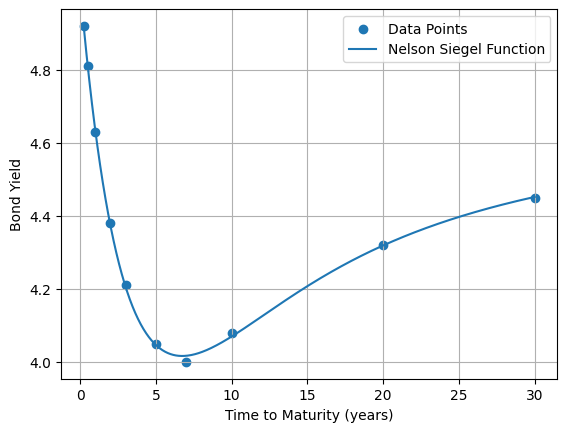

In [ ]:
T_plot = np.linspace(T.min(),T.max(),500)
Yield_plot = Nelson_Siegel_Function(T_plot, beta_0, beta_1, beta_2, tau)


plt.figure()
plt.scatter(T, yields,label = 'Data Points')
plt.plot(T_plot, Yield_plot, label = 'Nelson Siegel Function')
plt.xlabel('Time to Maturity (years)')
plt.ylabel('Bond Yield')
plt.legend()
plt.grid(True)
plt.show()
